In [1]:
############################# Plots for Movies! ###################################
# The purpose of this script is to ake various plots for various movies
# and run them in parallel and all that jazz so that we can make ool movies of 
# things.
#
# Notes:
# - This works best in xroms? xesmf_env? conda environment(s)
# 
###################################################################################

In [13]:
# Load in the packages 
import numpy as np
import glob
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterExponent
import warnings
import xarray as xr
import xesmf as xe
import os
#import xroms
from joblib import Parallel, delayed
from matplotlib import ticker
import cartopy.mpl.ticker as cticker
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
crs = ccrs.PlateCarree()
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

In [3]:
# Load in the model output(s)
model_output_std = xr.open_mfdataset('/pl/active/moriarty_lab/BriannaU/Paper1/2020_version/Output/dbsed0003/ocean_his_beaufort_shelf_2020_dbsed0003_*.nc')

In [4]:
model_output_std

<xarray.Dataset> Size: 603GB
Dimensions:                 (ocean_time: 962, tracer: 7, boundary: 4, NST: 5,
                             s_rho: 20, s_w: 21, eta_rho: 206, xi_rho: 608,
                             eta_u: 206, xi_u: 607, eta_v: 205, xi_v: 608,
                             eta_psi: 205, xi_psi: 607, Nbed: 11)
Coordinates:
  * s_rho                   (s_rho) float64 160B -0.975 -0.925 ... -0.075 -0.025
  * s_w                     (s_w) float64 168B -1.0 -0.95 -0.9 ... -0.05 0.0
    lon_rho                 (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(206, 608), meta=np.ndarray>
    lat_rho                 (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(206, 608), meta=np.ndarray>
    lon_u                   (eta_u, xi_u) float64 1MB dask.array<chunksize=(206, 607), meta=np.ndarray>
    lat_u                   (eta_u, xi_u) float64 1MB dask.array<chunksize=(206, 607), meta=np.ndarray>
    lon_v                   (eta_v, xi_v) float64 997kB dask.array<chunksize=(205, 608), meta=np.ndarray>
    lat_v                   (eta_v, xi_v) float64 997kB dask.array<chunksize=(205, 608), meta=np.ndarray>
    lon_psi                 (eta_psi, xi_psi) float64 995kB dask.array<chunksize=(205, 607), meta=np.ndarray>
    lat_psi                 (eta_psi, xi_psi) float64 995kB dask.array<chunksize=(205, 607), meta=np.ndarray>
  * ocean_time              (ocean_time) datetime64[ns] 8kB 2020-07-01T01:00:...
Dimensions without coordinates: tracer, boundary, NST, eta_rho, xi_rho, eta_u,
                                xi_u, eta_v, xi_v, eta_psi, xi_psi, Nbed
Data variables: (12/154)
    ntimes                  (ocean_time) int32 4kB 2125440 2125440 ... 2125440
    ndtfast                 (ocean_time) int32 4kB 20 20 20 20 ... 20 20 20 20
    dt                      (ocean_time) float64 8kB 5.0 5.0 5.0 ... 5.0 5.0 5.0
    dtfast                  (ocean_time) float64 8kB 0.25 0.25 ... 0.25 0.25
    dstart                  (ocean_time) datetime64[ns] 8kB 2020-07-01T01:00:...
    nHIS                    (ocean_time) int32 4kB 2160 2160 2160 ... 2160 2160
    ...                      ...
    Zo_bio                  (ocean_time, eta_rho, xi_rho) float64 964MB dask.array<chunksize=(161, 206, 608), meta=np.ndarray>
    active_layer_thickness  (ocean_time, eta_rho, xi_rho) float64 964MB dask.array<chunksize=(161, 206, 608), meta=np.ndarray>
    dep_net                 (ocean_time, eta_rho, xi_rho) float64 964MB dask.array<chunksize=(161, 206, 608), meta=np.ndarray>
    Dwave                   (ocean_time, eta_rho, xi_rho) float64 964MB dask.array<chunksize=(161, 206, 608), meta=np.ndarray>
    Pwave_bot               (ocean_time, eta_rho, xi_rho) float64 964MB dask.array<chunksize=(161, 206, 608), meta=np.ndarray>
    Uwave_rms               (ocean_time, eta_rho, xi_rho) float64 964MB dask.array<chunksize=(161, 206, 608), meta=np.ndarray>
Attributes: (12/49)
    file:              /scratch/alpine/brun1463/ROMS_scratch/Kakak3_Alpine_20...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             One-dimension (vertical) Sediment Toy
    var_info:          /projects/brun1463/COAWST/Workshop/COAWST-master/ROMS/...
    ...                ...
    compiler_command:  /curc/sw/install/intel/2022.1.2/mpi/2021.5.1/bin/mpifc
    compiler_flags:    -fp-model=precise -ip -O3
    tiling:            012x004
    history:           ROMS/TOMS, Version 3.9, Tuesday - December 10, 2024 - ...
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_st...
    CPP_options:       KAKTOVIK_AK_2020, ANA_BPFLUX, ANA_BSFLUX, ANA_BTFLUX, ...

In [5]:
# Load in the model grid
grid = xr.open_dataset('/projects/brun1463/ROMS/Kakak3_Alpine/Include/KakAKgrd_shelf_big010_smooth006.nc')
#grid = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/Code/Grids/KakAKgrd_shelf_big010_smooth006.nc') # UPDATE PATH

In [6]:
# Load in the wave forcing file 
wave_frc = xr.open_dataset('/projects/brun1463/ROMS/Kakak3_Alpine_2020/Include/wave_forcing_file_kaktovik_shelf_ww3_2020_data002.nc')

### Make a Bunch of Functions

In [23]:
# Make a function to calculate the sediment flux in the 
# u direction for all sediment classes combined
def calc_u_depth_int_ssc_flux_allsed(model_output, regridder_u2rho):
    """
    The purpose of this function is to take a given model output file, load 
    in the output, and caluclate the time-averaged, depth-integrated suspended 
    sediment flux in the eastward direction for all sediment classes added
    together.

    Parameters
    ----------
    filename : The name/path of the model output file.

    Returns
    -------
    depth_int_ssc_flux_east_allsed: Depth-integrated SSC flux in eastward direction
    for all sediment classes combined 
    depth_int_ssc_allsed: Time series of depth-integrated ssc 

    """
    
    # Add all the sediment classes together
    ssc_allsed_tmp = model_output.mud_01 + model_output.mud_02 + model_output.sand_01 + model_output.sand_02 + model_output.sand_03
    
    # To collapse to horizontal, multiply each layer by its
    # thickness
    # Calculate the time-varying thickness of the cells
    dz = abs(model_output.z_w[:-1,:,:].values - model_output.z_w[1:,:,:].values)
    
    # Pull out the u velocities at all times, depths, spaces
    u_tmp = model_output.u
    
    # Interpolate them onto rho points 
    u_tmp_rho = regridder_u2rho(u_tmp)
    
    # Pull out the thickness of the cell in the y direction 
    #dy = 1.0/model_output.pn
    
    # Use all of this to calculate depth-integrated sediment flux
    # First just calculate flux at all times over all space
    ssc_flux_allsed = ((ssc_allsed_tmp*u_tmp_rho)*(dz))
    
    # Then depth-integrated by summing over depth and dividing by dy
    depth_int_ssc_flux_u_allsed = (ssc_flux_allsed.sum(dim='s_rho'))
    
    # Calculate depth-integrated ssc
    depth_int_ssc_allsed = (((ssc_allsed_tmp*dz)).sum(dim='s_rho'))
    
    # Divide by bathymetry to get depth-averaged SSC (kg/m3)
    depth_avg_ssc_allsed = depth_int_ssc_allsed/model_output.bath[:,:].values
    
    # Return the depth-integrated u flux for all sediment classes
    return(depth_int_ssc_flux_u_allsed, depth_avg_ssc_allsed)


In [24]:
# Make a function to calculate the sediment flux in the 
# v direction for all sediment classes combined
def calc_v_depth_int_ssc_flux_allsed(model_output, regridder_v2rho):
    """
    The purpose of this function is to take a given model output file, load 
    in the output, and caluclate the time-averaged, depth-integrated suspended 
    sediment flux in the v direction for all sediment classes added
    together.

    Parameters
    ----------
    filename : The name/path of the model output file.

    Returns
    -------
    depth_int_ssc_flux_north_allsed: Depth-integrated SSC flux in northward direction
    for all sediment classes combined 

    """
    
    # Add all the sediment classes together
    ssc_allsed_tmp = model_output.mud_01 + model_output.mud_02 + model_output.sand_01 + model_output.sand_02 + model_output.sand_03
    
    # To collapse to horizontal, multiply each layer by its
    # thickness
    # Calculate the time-varying thickness of the cells
    dz = abs(model_output.z_w[:-1,:,:].values - model_output.z_w[1:,:,:].values)
    
    # Pull out the v velocities at all times, depths, spaces
    v_tmp = model_output.v
    
    # Interpolate them onto rho points 
    v_tmp_rho = regridder_v2rho(v_tmp)
    
    # Pull out the thickness of the cell in the x direction 
    #dx = 1.0/model_output.pm
    
    # Use all of this to calculate depth-integrated sediment flux
    # First just calculate flux at all times over all space
    ssc_flux_allsed = ((ssc_allsed_tmp*v_tmp_rho)*(dz))
    
    # Then depth-integrated by summing over depth and dividing by dx
    depth_int_ssc_flux_v_allsed = (ssc_flux_allsed.sum(dim='s_rho'))
    
    # Return the depth-integrated v flux for all sediment classes
    return(depth_int_ssc_flux_v_allsed)

### Prep for Movies/Plots

In [14]:
# Set the input and output grids, and sepcify the lat/lon
# Since we are looking at ubar and vbar, we will use lon_u and lat_u as the primary lat/lon for the grid 
# and make another with lat_v and lon_v
# U input grid 
ds_in_u = grid.copy() # need to use lon_180 for this grid 
ds_in_u['lon'] = (('eta_u', 'xi_u'), ds_in_u.lon_u.values)
ds_in_u['lat'] = (('eta_u', 'xi_u'), ds_in_u.lat_u.values)
# V input grid 
ds_in_v = grid.copy() # need to use lon_180 for this grid 
ds_in_v['lon'] = (('eta_v', 'xi_v'), ds_in_v.lon_v.values)
ds_in_v['lat'] = (('eta_v', 'xi_v'), ds_in_v.lat_v.values)

# Output grid (ROMS rho grid)
ds_out_rho = grid.copy()
ds_out_rho['lat'] = (('eta_rho', 'xi_rho'), ds_out_rho.lat_rho.values)
ds_out_rho['lon'] = (('eta_rho', 'xi_rho'), ds_out_rho.lon_rho.values)

# Add masks 
# ex: ds["mask"] = xr.where(~np.isnan(ds["zeta"].isel(ocean_time=0)), 1, 0)
# Input grid (HYCOM)
# this is only a surface mask - which is what we want 
# U
ds_in_u['mask'] = (('eta_u', 'xi_u'), ds_in_u.mask_u.values)
# V
ds_in_v['mask'] = (('eta_v', 'xi_v'), ds_in_v.mask_v.values)
# Output grid (ROMS rho grid)
ds_out_rho['mask'] = (('eta_rho', 'xi_rho'), ds_out_rho.mask_rho.values)

# Regrid from u grid to rho grid with the masks included and extrapolation used 
regridder_u2rho = xe.Regridder(ds_in_u, ds_out_rho, method="bilinear", extrap_method='inverse_dist') #extrap_method="nearest_s2d"
regridder_u2rho
# Regrid from v grid to rho grid with the masks included and extrapolation used 
regridder_v2rho = xe.Regridder(ds_in_v, ds_out_rho, method="bilinear", extrap_method='inverse_dist') #extrap_method="nearest_s2d"
regridder_v2rho

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_205x608_206x608.nc 
Reuse pre-computed weights? False 
Input grid shape:           (205, 608) 
Output grid shape:          (206, 608) 
Periodic in longitude?      False

### Movie: Depth-Averaged Currents, SSC and Sed Fluxes, Waves, and Bed Shear Stress?  
Make multipanel movie of currents, SSC, waves, and bed shear stress things to show general model things

In [9]:
# Pull out shapes
eta_rho_len = len(grid.eta_rho)
xi_rho_len = len(grid.xi_rho)

# Make land mask
temp_mask = grid.mask_rho.values
temp_mask = np.where(temp_mask==0, np.nan, temp_mask)

In [10]:
# Load in nan masks 
mask_rho_nan = xr.open_dataset('/projects/brun1463/ROMS/Kakak3_Alpine/Scripts_2/Analysis/Nudge_masks/nudge_mask_rho_ones_nans.nc') # UPDATE PATH
mask_rho_zeros = xr.open_dataset('/projects/brun1463/ROMS/Kakak3_Alpine/Scripts_2/Analysis/Nudge_masks/nudge_mask_rho_zeros_ones.nc')
# mask_rho_nan = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/Code/Nudge_masks/nudge_mask_rho_ones_nans.nc')
# mask_rho_zeros = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/Code/Nudge_masks/nudge_mask_rho_zeros_ones.nc')

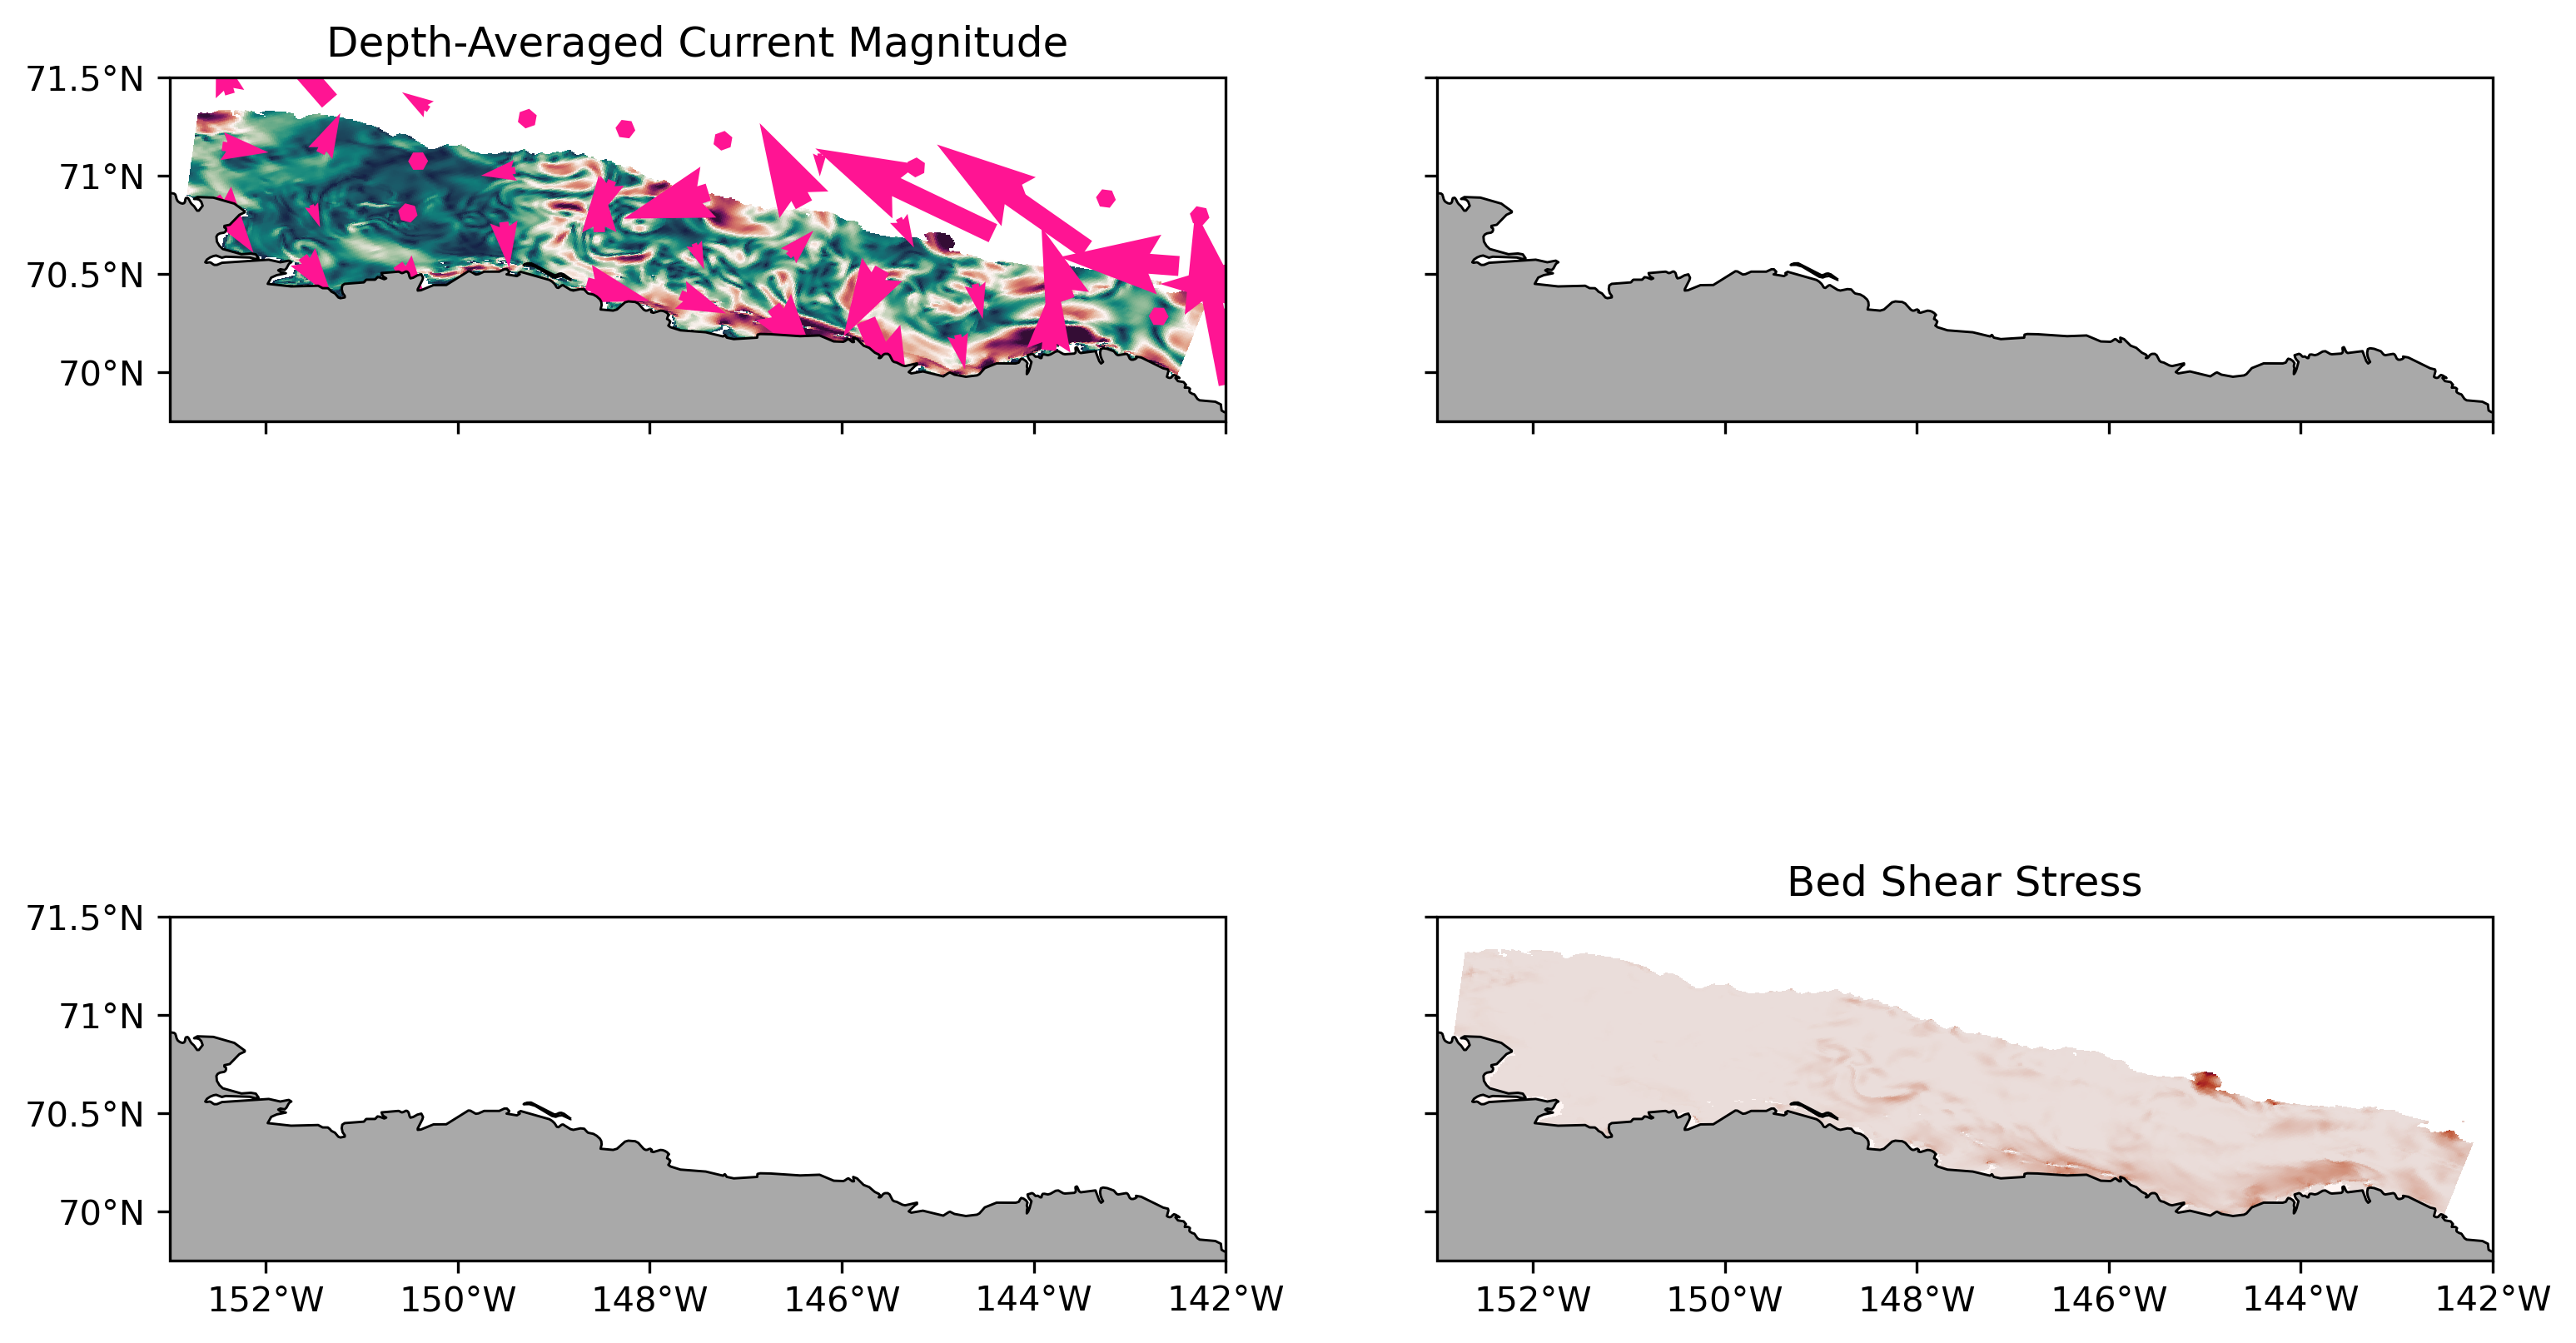

In [11]:
# First make a plot to see how this looks
# (so for each time step, need to get currents as 
# shading and quivers, SSC and sedimetn flux, wave heights, 
# and bed shear stress)

# Set the time to look at
time_idx = 90

# Set the speeds
speed_min = 0 # m/s
speed_max = 0.2 # m/s
cmap_spd = cmo.curl

# Set the SSC stuff
ssc_min = 0 # kg/m3
ssc_max = 0.01 # kg/m3
cmap_ssc = cmo.turbid

# Calculate the different things 
# Current magnitude
cur_mag = np.sqrt(((model_output_std.ubar_eastward[time_idx,:,:])**2) + ((model_output_std.vbar_northward[time_idx,:,:])**2))
# Total depth-averaged SSC

# Depth-integrated sediment flux
u_depth_int_ssflux, depth_avg_ssc = calc_u_depth_int_ssc_flux_allsed(model_output, regridder_u2rho)
v_depth_int_ssflux = calc_v_depth_int_ssc_flux_allsed(model_output, regridder_v2rho)
# 

# Set the number of quivers
n_quiv = 50

# Make the figure; add things to make it the right ratios and all that
nrows = 2; ncols = 2
fig, ax = plt.subplots(nrows, ncols, figsize=(12, 8), # ((9.75/3)*1.9, 5); (4.5, 5) 
                       #sharex=True, sharey=True, dpi=300,
                       dpi=300, subplot_kw={'projection': crs})

# Depth-averaged current magnitude
m1 = ax[0,0].pcolormesh(grid.lon_rho.values, grid.lat_rho.values, cur_mag*mask_rho_nan.nudge_mask_rho_nan, 
                       cmap=cmap_spd, vmin = speed_min, vmax=speed_max)
ax[0,0].set_title('Depth-Averaged Current Magnitude')
#fig.colorbar(m1, ax=ax[0,0], label='[C]', extend='both')
# Add quivers of the current magnitude
q1 = ax[0,0].quiver(grid.lon_rho[::n_quiv,::n_quiv].values, grid.lat_rho[::n_quiv,::n_quiv].values, 
                   model_output_std.ubar_eastward[time_idx,::n_quiv,::n_quiv], model_output_std.vbar_northward[time_idx,::n_quiv,::n_quiv], 
                   color='deeppink', width=0.2,
                   angles='xy', scale_units='xy', units='xy')


# Surface u ice
# m1 = ax[0,1].pcolormesh(x_rho[min_xi:max_xi]/1000, y_rho[min_eta:max_eta]/1000, ds_avg.u[tidx,-1,:,:].isel(eta_rho=eta_slice, xi_u=xi_slice), 
#                         cmap=cmo.curl, vmin=speed_min, vmax=speed_max)
# ax[0,1].set_title('Water U (ice)')
# #fig.colorbar(m1, ax=ax[0,1], label='[g/kg]', extend='both')

# Significant wave height - * NEED TO FIX TIME *
m4 = ax[1,1].pcolormesh(grid.lon_rho.values, grid.lat_rho.values, wave_frc.Hwave[time_idx,:,:]*mask_rho_nan.nudge_mask_rho_nan,
                         cmap=cmo.tempo, vmin=0, vmax=0.5)
ax[1,1].set_title('Significant Wave Height')

# Total bed shear stress
m4 = ax[1,1].pcolormesh(grid.lon_rho.values, grid.lat_rho.values, model_output_std.bstrcwmax[time_idx,:,:]*mask_rho_nan.nudge_mask_rho_nan,
                         cmap=cmo.amp, vmin=0, vmax=0.2)
ax[1,1].set_title('Bed Shear Stress')

# Loop through axes to add features
for r in range(2):
    for j in range(2):
        # Plot bathymetry 
        #c1 = ax[r,j].contour(grid.lon_rho, grid.lat_rho, grid.h*mask_rho_nan.nudge_mask_rho_nan, lev_bathy, colors='darkslategrey', linewidth=2)
        #ax[r,j].clabel(c1, inline=True, fontsize=10, colors='white')
        
        # Set extent and map features
        #ax[r].set_extent([-153.5,-141.4,69.5, 71.5],ccrs.PlateCarree())
        ax[r,j].set_extent([-153,-142.2,69.75, 71.5],ccrs.PlateCarree())
        # ax.set_aspect(lat_rad)
        ax[r,j].add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                    facecolor='darkgray'), linewidth=.7)
        ax[r,j].coastlines(resolution='10m', linewidth=.7)

        # Set tick locations
        xticks = [-152, -150, -148, -146, -144, -142]
        yticks = [70, 70.5, 71, 71.5]

        ax[r,j].set_yticks(yticks, crs=ccrs.PlateCarree())
        ax[r,j].yaxis.set_major_formatter(cticker.LatitudeFormatter())
        ax[r,j].set_xticks(xticks, crs=ccrs.PlateCarree())
        ax[r,j].xaxis.set_major_formatter(cticker.LongitudeFormatter())

        # ---- Remove labels for first two panels ----
        if r in [0]:
            ax[r,j].tick_params(labelbottom=False)
        if j in [1]:
            ax[r,j].tick_params(labelleft=False)

        # Fix the aspect ratio
        lon_min, lon_max = -153, -142.2
        lat_min, lat_max = 69.75, 71.5
        mid_lat = (lat_min + lat_max) / 2
        aspect = (lon_max - lon_min) * np.cos(np.deg2rad(mid_lat)) / (lat_max - lat_min)
        ax[r,j].set_aspect(aspect)



# # Set consistent axis limits
# for i in range(nrows):
#     for j in range(ncols):
#         ax[i,j].set_xlabel('Along-shelf distance [km]')
#         ax[i,j].set_aspect(1.0)

# #ax[0,0].set_ylabel('Across-shelf distance [km]')
# #ax[1,0].set_ylabel('Across-shelf Distance [km]')
# ax[0,0].set_xlabel('')
# ax[0,1].set_xlabel('')
# ax[1,0].set_xlabel('')
# ax[1,1].set_xlabel('')
# ax[0,2].set_xlabel('')
# ax[1,2].set_xlabel('')
# fig.text(0.39, 0.05, 'Along-shelf Distance [km]')
# fig.text(0.03, 0.30, 'Across-shelf Distance [km]', rotation=90)
# fig.suptitle(str(ds_avg.ocean_time.values[tidx])[:10])

# plt.subplots_adjust(wspace=0.1)

In [4]:
# Make a function to plot each time step and save it somewhere

In [ ]:
# Call the function in parallel to make all the plots for the movie

### Movie: Depth-Averaged Currents, SSC and Sed Fluxes, and Bed Shear Stress  
Make a plot of three panels - one with bed shear stress, currents, and ssc and sediment fluxes

In [ ]:
# Prep the data
# Want bed shear stress in top panel,
# then current magnitude and direction in middle, 
# and SSC and sediment flux in bottom panel

NameError: name 'ds_avg' is not defined

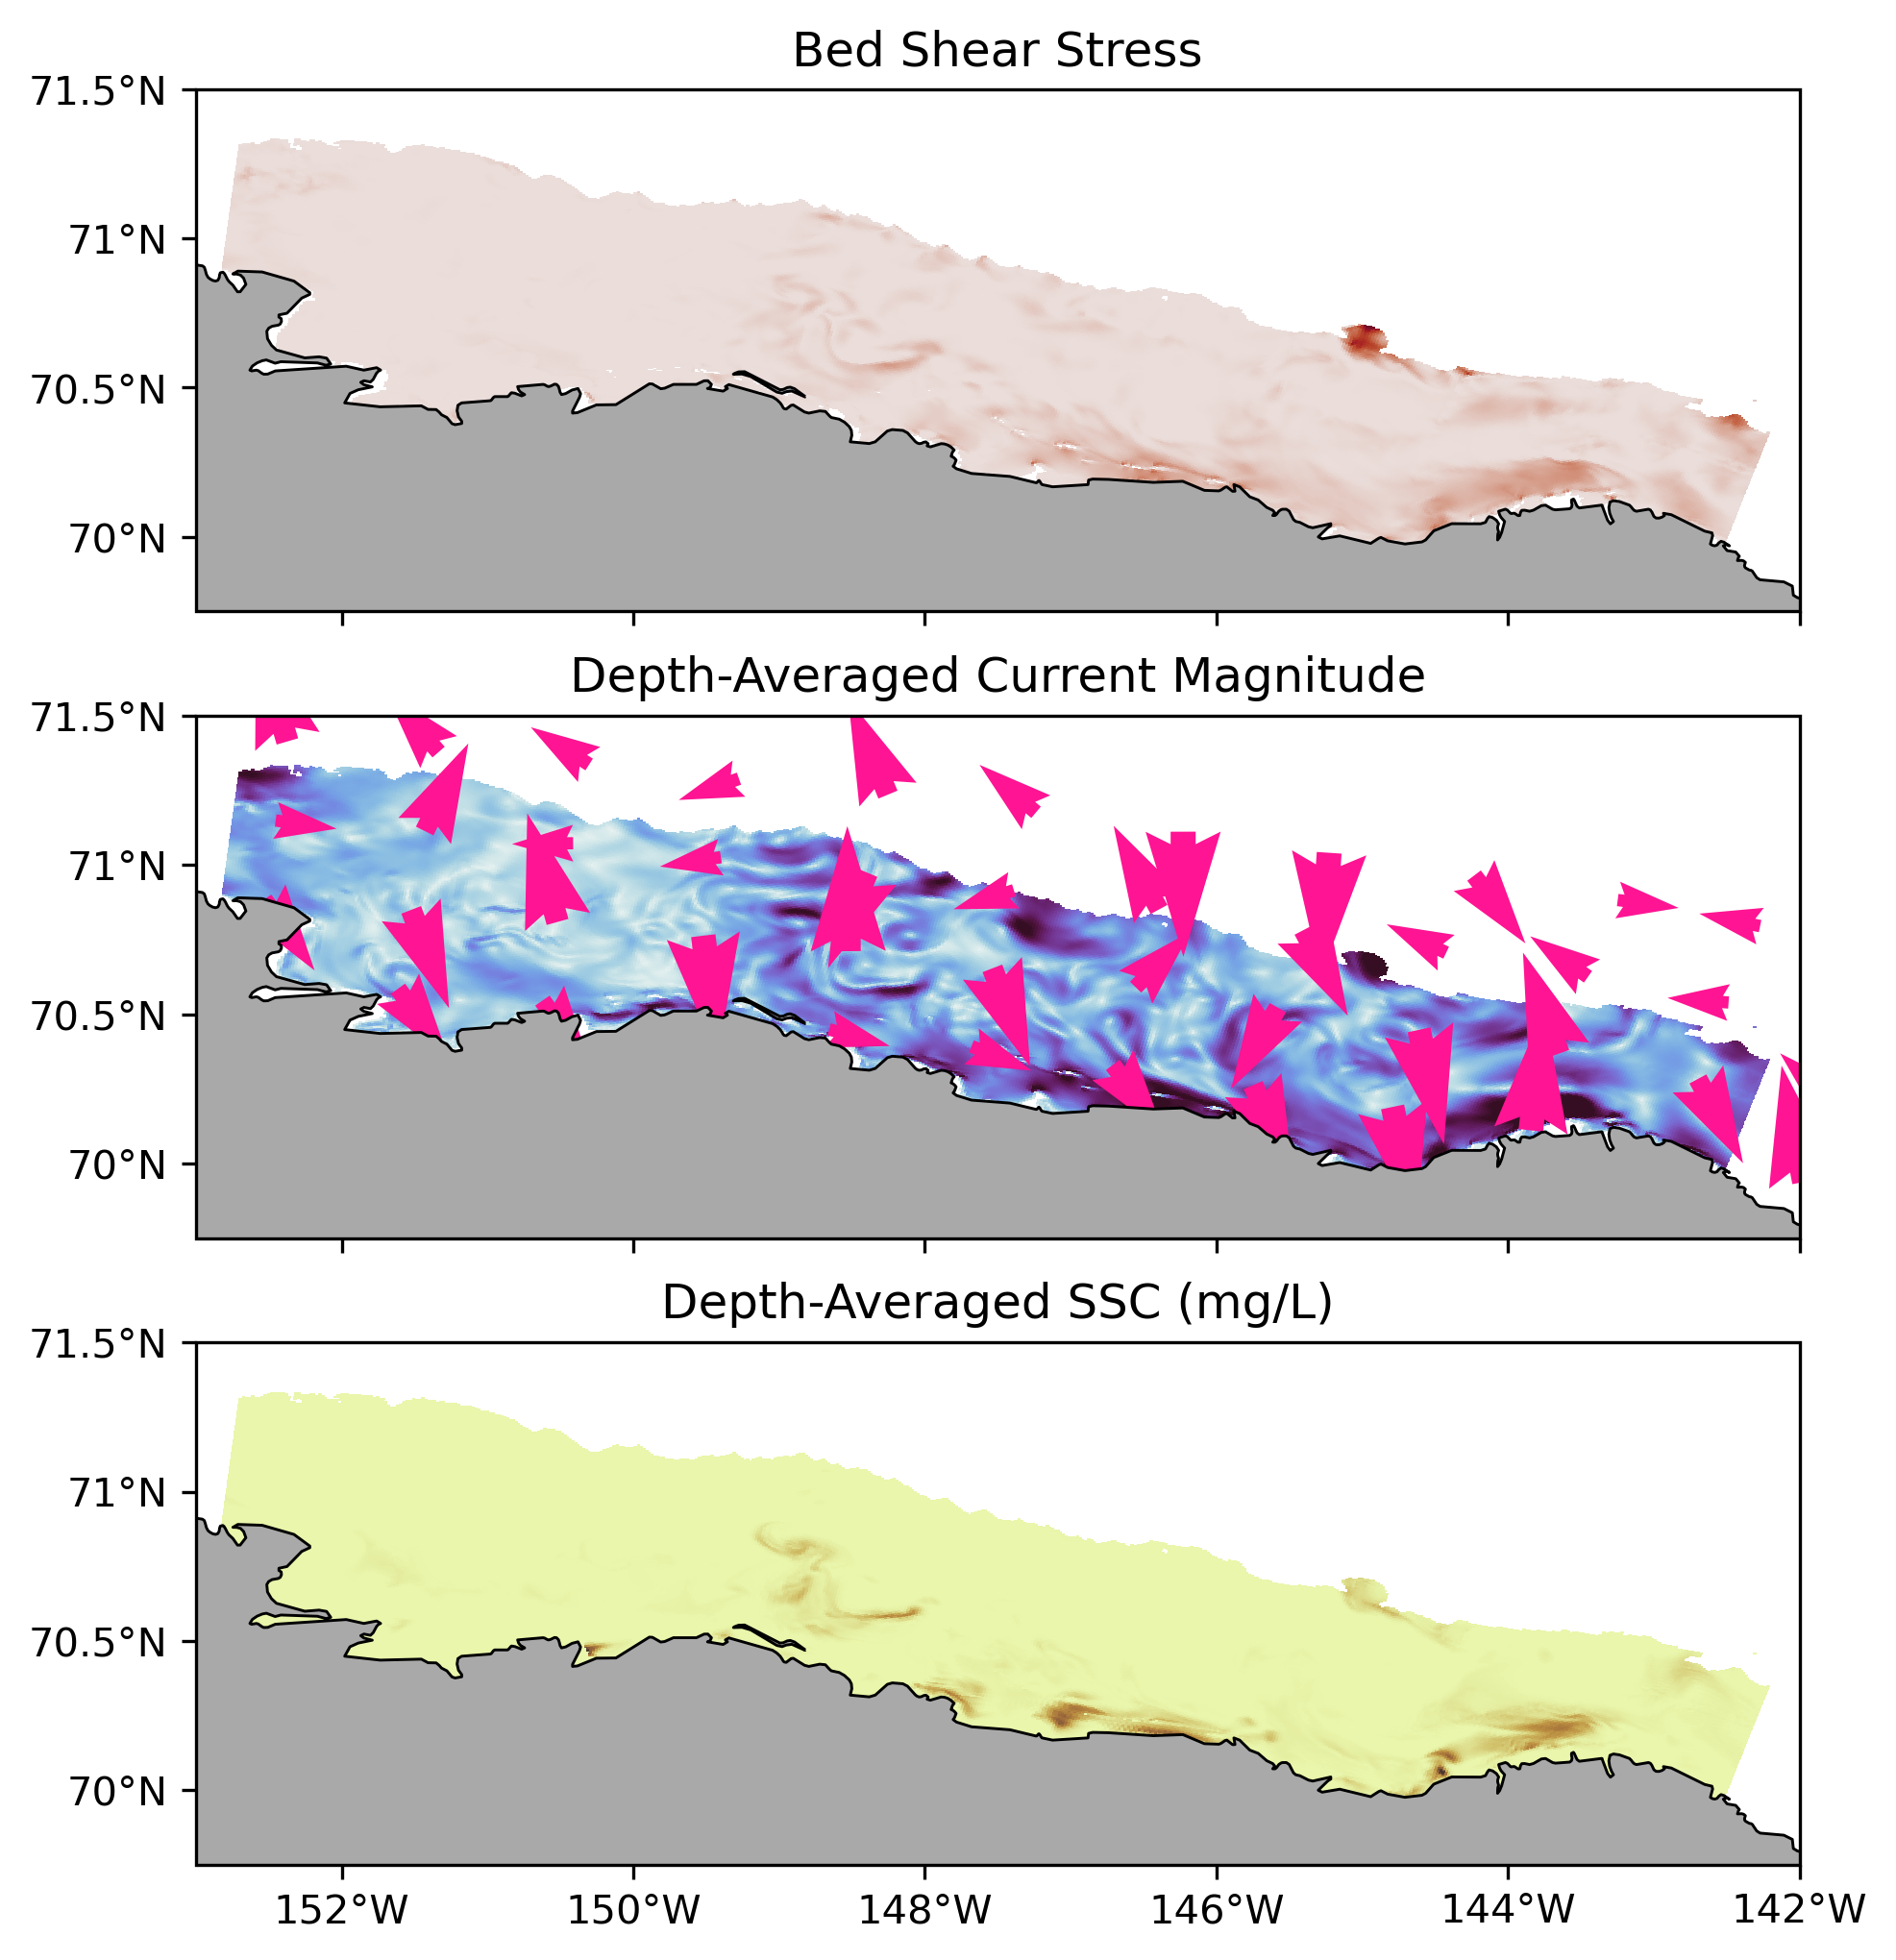

In [32]:
# Make the sample figure

# Set the time to look at
time_idx = 90

# Set the speeds
speed_min = 0 # m/s
speed_max = 0.2 # m/s
cmap_spd = cmo.dense

# Set the SSC stuff
ssc_min = 0 # kg/m3
ssc_max = 0.01 # kg/m3
cmap_ssc = cmo.turbid

# Calculate the different things 
# Current magnitude
cur_mag = np.sqrt(((model_output_std.ubar_eastward[time_idx,:,:])**2) + ((model_output_std.vbar_northward[time_idx,:,:])**2))
# Total depth-averaged SSC


# Depth-integrated sediment flux
u_depth_int_ssflux, depth_avg_ssc = calc_u_depth_int_ssc_flux_allsed(model_output_std.isel(ocean_time=time_idx), regridder_u2rho)
v_depth_int_ssflux = calc_v_depth_int_ssc_flux_allsed(model_output_std.isel(ocean_time=time_idx), regridder_v2rho)

# Set the number of quivers
n_quiv = 50

# Make the figure; add things to make it the right ratios and all that
nrows = 3; ncols = 1
fig, ax = plt.subplots(nrows, ncols, figsize=(12, 8), # ((9.75/3)*1.9, 5); (4.5, 5) 
                       #sharex=True, sharey=True, dpi=300,
                       dpi=300, subplot_kw={'projection': crs})

# Total bed shear stress
m1 = ax[0].pcolormesh(grid.lon_rho.values, grid.lat_rho.values, model_output_std.bstrcwmax[time_idx,:,:]*mask_rho_nan.nudge_mask_rho_nan,
                         cmap=cmo.amp, vmin=0, vmax=0.2)
ax[0].set_title('Bed Shear Stress')

# Depth-averaged current magnitude
m2 = ax[1].pcolormesh(grid.lon_rho.values, grid.lat_rho.values, cur_mag*mask_rho_nan.nudge_mask_rho_nan, 
                       cmap=cmap_spd, vmin = speed_min, vmax=speed_max)
ax[1].set_title('Depth-Averaged Current Magnitude')
#fig.colorbar(m1, ax=ax[0,0], label='[C]', extend='both')
# Add quivers of the normalized current current 
q1 = ax[1].quiver(grid.lon_rho[::n_quiv,::n_quiv].values, grid.lat_rho[::n_quiv,::n_quiv].values, 
                   model_output_std.ubar_eastward[time_idx,::n_quiv,::n_quiv]/cur_mag[::n_quiv,::n_quiv], 
                   model_output_std.vbar_northward[time_idx,::n_quiv,::n_quiv]/cur_mag[::n_quiv,::n_quiv], 
                   color='deeppink', width=0.2,
                   angles='xy', scale_units='xy', units='xy')

# SSC and sediment flux
m4 = ax[2].pcolormesh(grid.lon_rho.values, grid.lat_rho.values,depth_avg_ssc[:,:]*mask_rho_nan.nudge_mask_rho_nan*1000,
                         cmap=cmap_ssc, vmin=0, vmax=10)
ax[2].set_title('Depth-Averaged SSC (mg/L)')

# Loop through axes to add features
for r in range(3):
    # Plot bathymetry 
    #c1 = ax[r,j].contour(grid.lon_rho, grid.lat_rho, grid.h*mask_rho_nan.nudge_mask_rho_nan, lev_bathy, colors='darkslategrey', linewidth=2)
    #ax[r,j].clabel(c1, inline=True, fontsize=10, colors='white')
    
    # Set extent and map features
    #ax[r].set_extent([-153.5,-141.4,69.5, 71.5],ccrs.PlateCarree())
    ax[r].set_extent([-153,-142.2,69.75, 71.5],ccrs.PlateCarree())
    # ax.set_aspect(lat_rad)
    ax[r].add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                facecolor='darkgray'), linewidth=.7)
    ax[r].coastlines(resolution='10m', linewidth=.7)

    # Set tick locations
    xticks = [-152, -150, -148, -146, -144, -142]
    yticks = [70, 70.5, 71, 71.5]

    ax[r].set_yticks(yticks, crs=ccrs.PlateCarree())
    ax[r].yaxis.set_major_formatter(cticker.LatitudeFormatter())
    ax[r].set_xticks(xticks, crs=ccrs.PlateCarree())
    ax[r].xaxis.set_major_formatter(cticker.LongitudeFormatter())

    # ---- Remove labels for first two panels ----
    if r in [0,1]:
        ax[r].tick_params(labelbottom=False)

    # Fix the aspect ratio
    lon_min, lon_max = -153, -142.2
    lat_min, lat_max = 69.75, 71.5
    mid_lat = (lat_min + lat_max) / 2
    aspect = (lon_max - lon_min) * np.cos(np.deg2rad(mid_lat)) / (lat_max - lat_min)
    ax[r].set_aspect(aspect)

fig.suptitle(str(ds_avg.ocean_time.values[time_idx])[:10])

# plt.subplots_adjust(wspace=0.1)
